Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4682.51it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


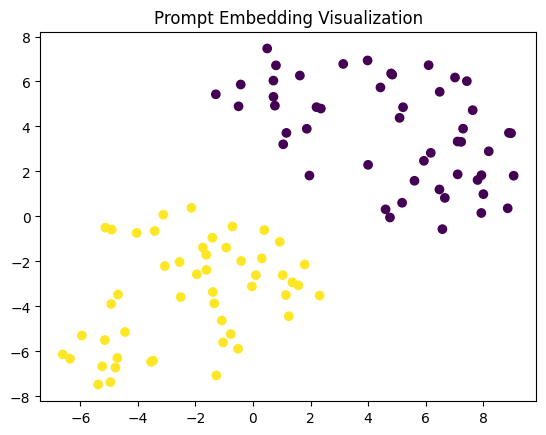

In [3]:
from sentence_transformers import SentenceTransformer
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()

df = pd.read_csv("../dataset/prompts.csv")

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(df["prompt"].tolist())

tsne = TSNE(n_components=2)

reduced = tsne.fit_transform(embeddings)

plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=df["label"]
)

plt.title("Prompt Embedding Visualization")

plt.show()